<a href="https://colab.research.google.com/github/omega-u20/SmartCare-HospitalManagement/blob/main/Task5_Model_Development.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 05 – Machine Learning Model Development


## 0. Mount Google Drive and Load Data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

DATA_FOLDER = '/content/drive/MyDrive/CCS3440 - Asg 2'

Mounted at /content/drive


In [ ]:
!pip install xgboost -q

In [ ]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from xgboost import XGBClassifier
import joblib

pd.set_option('display.max_columns', None)
RANDOM_STATE = 42

df = pd.read_csv(f'{DATA_FOLDER}/smartcare_ai_dataset_1000.csv')
print('Dataset shape:', df.shape)

Dataset shape: (1000, 33)


## 1. Rebuild Preprocessing Pipeline (from Task 03)

Same cleaning and feature engineering decisions as Task 03, applied here in one place so this notebook is self-contained.

In [ ]:
df['room_type'] = df['room_type'].fillna('Not Admitted')
df = df.drop_duplicates()

df_model = df.drop(columns=['record_id', 'patient_id', 'no_show', 'disease_risk_level'])

# Date feature extraction
df_model['appointment_date'] = pd.to_datetime(df_model['appointment_date'])
df_model['appointment_month'] = df_model['appointment_date'].dt.month
df_model['appointment_dayofweek'] = df_model['appointment_date'].dt.dayofweek
df_model = df_model.drop(columns=['appointment_date'])

# Engineered features
df_model['missed_appointment_rate'] = np.where(
    df_model['previous_appointments'] > 0,
    df_model['missed_previous_appointments'] / df_model['previous_appointments'], 0)
df_model['is_hypertensive'] = ((df_model['systolic_bp'] >= 140) | (df_model['diastolic_bp'] >= 90)).astype(int)
df_model['avg_charge_per_treatment'] = np.where(
    df_model['treatments_count'] > 0,
    df_model['total_bill_lkr'] / df_model['treatments_count'], df_model['total_bill_lkr'])

# Encoding
categorical_cols = ['gender', 'blood_group', 'department', 'diagnosis', 'room_type',
                     'payment_status', 'payment_method', 'appointment_status']
df_model = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)

print('Shape after preprocessing:', df_model.shape)
df_model.head()

Shape after preprocessing: (1000, 59)


,age,waiting_days,previous_appointments,missed_previous_appointments,admitted,length_of_stay_days,previous_admissions,systolic_bp,diastolic_bp,blood_sugar_mg_dl,cholesterol_mg_dl,bmi,lab_tests_count,treatments_count,consultation_fee_lkr,room_charge_lkr,lab_charge_lkr,medicine_charge_lkr,total_bill_lkr,readmitted_30_days,appointment_month,appointment_dayofweek,missed_appointment_rate,is_hypertensive,avg_charge_per_treatment,gender_Male,blood_group_A-,blood_group_AB+,blood_group_AB-,blood_group_B+,blood_group_B-,blood_group_O+,blood_group_O-,department_General Medicine,department_Laboratory Services,department_Neurology,department_Orthopedics,department_Pediatrics,department_Radiology,diagnosis_Back Pain,diagnosis_Chest Pain,diagnosis_Diabetes,diagnosis_Fever,diagnosis_Fracture,diagnosis_Hypertension,diagnosis_Kidney Infection,diagnosis_Migraine,diagnosis_Pneumonia,room_type_ICU,room_type_Not Admitted,room_type_Private Room,payment_status_Partially Paid,payment_status_Unpaid,payment_method_Cash,payment_method_Insurance,payment_method_Online,appointment_status_Completed,appointment_status_No-Show,appointment_status_Scheduled
0,53,10,1,0,0,0,1,127,75,117,211,26.1,0,3,2000,0,0,11596,13596,0,4,3,0.000000,0,4532.0,True,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,True,False,True,False,False
1,26,2,3,1,0,0,0,130,73,136,173,32.8,0,1,2000,0,0,3652,5652,0,5,3,0.333333,0,5652.0,True,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,True,False,True,False,False
2,22,22,7,1,0,0,1,141,64,90,176,29.4,1,0,2500,0,1200,2562,6262,0,7,2,0.142857,1,6262.0,True,False,False,False,True,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,True,False,True,False,False,True,False
3,44,16,1,0,0,0,0,124,82,126,189,24.9,2,1,2000,0,5000,10262,17262,0,10,3,0.000000,0,17262.0,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,True,False,False
4,51,12,4,0,0,0,1,119,81,65,195,27.0,2,0,4000,0,6000,10414,20414,0,12,3,0.000000,0,20414.0,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,True,False,False,False,False,True


## 2. Train-Test Split

**Decision:** 80/20 split, with `stratify=y` so both the training and test sets keep the same ~75/25 class balance found in Task 04. Without stratification, a random split could accidentally under- or over-represent the minority (readmitted) class in the test set, making evaluation unreliable.

In [ ]:
X = df_model.drop(columns=['readmitted_30_days'])
y = df_model['readmitted_30_days']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

print('Training set:', X_train.shape, ' | Test set:', X_test.shape)
print()
print('Train class balance:')
print(y_train.value_counts(normalize=True).round(3))
print()
print('Test class balance:')
print(y_test.value_counts(normalize=True).round(3))

Training set: (800, 58)  | Test set: (200, 58)

Train class balance:
readmitted_30_days
0    0.748
1    0.252
Name: proportion, dtype: float64

Test class balance:
readmitted_30_days
0    0.745
1    0.255
Name: proportion, dtype: float64


## 3. Feature Scaling

**Important:** the scaler is fit only on `X_train`, then applied (`.transform`, not `.fit_transform`) to `X_test`. This prevents information from the test set leaking into training, which would make our evaluation in Task 06 overly optimistic and unrealistic.

In [ ]:
numeric_cols = ['age', 'waiting_days', 'previous_appointments', 'missed_previous_appointments',
                 'admitted', 'length_of_stay_days', 'previous_admissions', 'systolic_bp', 'diastolic_bp',
                 'blood_sugar_mg_dl', 'cholesterol_mg_dl', 'bmi', 'lab_tests_count', 'treatments_count',
                 'consultation_fee_lkr', 'room_charge_lkr', 'lab_charge_lkr', 'medicine_charge_lkr',
                 'total_bill_lkr', 'appointment_month', 'appointment_dayofweek',
                 'missed_appointment_rate', 'is_hypertensive', 'avg_charge_per_treatment']

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

print('Scaling done. Train mean (should be ~0):', X_train_scaled[numeric_cols].mean().mean().round(3))

Scaling done. Train mean (should be ~0): 0.0


## 4. Model Selection

We train **five** classification models to compare, covering different types of algorithms:

| Model | Type | Why included |
|---|---|---|
| Logistic Regression | Linear | Simple, interpretable baseline |
| Decision Tree | Tree-based | Captures non-linear rules, easy to explain |
| Random Forest | Ensemble (bagging) | Usually strong, handles feature interactions well |
| K-Nearest Neighbors | Distance-based | Different learning approach, sensitive to scaling |
| XGBoost | Ensemble (boosting) | Often top-performing on tabular healthcare data |

This satisfies the "at least THREE models" requirement with room to spare, giving a more meaningful comparison in Task 06.

### 4.1 Logistic Regression

In [ ]:
log_reg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)
log_reg.fit(X_train_scaled, y_train)
print('Logistic Regression trained.')

Logistic Regression trained.


**Note:** `class_weight='balanced'` is used because of the class imbalance found in Task 04 (74.7% vs 25.3%). This makes the model pay proportionally more attention to the minority (readmitted) class instead of just predicting the majority class most of the time.

### 4.2 Decision Tree (with hyperparameter tuning)

**Decision:** Decision trees can easily overfit if left unrestricted (they'll keep splitting until every leaf is pure). We use `GridSearchCV` to search over `max_depth` and `min_samples_leaf` with 5-fold cross-validation, selecting the combination that gives the best F1-score on the training folds.

In [ ]:
dt_params = {'max_depth': [3, 5, 7, 10, None], 'min_samples_leaf': [1, 5, 10]}

dt_grid = GridSearchCV(DecisionTreeClassifier(class_weight='balanced', random_state=RANDOM_STATE),
                        dt_params, cv=5, scoring='f1', n_jobs=-1)
dt_grid.fit(X_train_scaled, y_train)

decision_tree = dt_grid.best_estimator_
print('Best Decision Tree params:', dt_grid.best_params_)
print('Best CV F1-score:', round(dt_grid.best_score_, 3))

Best Decision Tree params: {'max_depth': 5, 'min_samples_leaf': 10}
Best CV F1-score: 0.883


### 4.3 Random Forest (with hyperparameter tuning)

In [ ]:
rf_params = {'n_estimators': [100, 200], 'max_depth': [5, 10, None], 'min_samples_leaf': [1, 5]}

rf_grid = GridSearchCV(RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE),
                        rf_params, cv=5, scoring='f1', n_jobs=-1)
rf_grid.fit(X_train_scaled, y_train)

random_forest = rf_grid.best_estimator_
print('Best Random Forest params:', rf_grid.best_params_)
print('Best CV F1-score:', round(rf_grid.best_score_, 3))

Best Random Forest params: {'max_depth': 10, 'min_samples_leaf': 1, 'n_estimators': 100}
Best CV F1-score: 0.883


### 4.4 K-Nearest Neighbors

**Decision:** KNN has no built-in way to weight classes, so it is more sensitive to imbalance than the other models. We test a small range of `k` values via grid search. KNN relies entirely on distance between points, which is exactly why scaling (Task 03/05 Section 3) matters most for this model.

In [ ]:
knn_params = {'n_neighbors': [3, 5, 7, 9, 11]}

knn_grid = GridSearchCV(KNeighborsClassifier(), knn_params, cv=5, scoring='f1', n_jobs=-1)
knn_grid.fit(X_train_scaled, y_train)

knn = knn_grid.best_estimator_
print('Best K:', knn_grid.best_params_)
print('Best CV F1-score:', round(knn_grid.best_score_, 3))

Best K: {'n_neighbors': 7}
Best CV F1-score: 0.806


### 4.5 XGBoost

**Decision:** `scale_pos_weight` is set to the ratio of negative-to-positive samples in the training set, which is XGBoost's equivalent of `class_weight='balanced'` — it tells the model to penalise mistakes on the minority (readmitted) class more heavily.

In [ ]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print('scale_pos_weight:', round(scale_pos_weight, 2))

xgb_params = {'n_estimators': [100, 200], 'max_depth': [3, 5, 7], 'learning_rate': [0.05, 0.1]}

xgb_grid = GridSearchCV(
    XGBClassifier(scale_pos_weight=scale_pos_weight, eval_metric='logloss', random_state=RANDOM_STATE),
    xgb_params, cv=5, scoring='f1', n_jobs=-1)
xgb_grid.fit(X_train_scaled, y_train)

xgboost_model = xgb_grid.best_estimator_
print('Best XGBoost params:', xgb_grid.best_params_)
print('Best CV F1-score:', round(xgb_grid.best_score_, 3))

scale_pos_weight: 2.96
Best XGBoost params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}
Best CV F1-score: 0.884


## 5. Comparative Analysis on Test Set

All five trained models are now evaluated on the held-out **test set** (data none of them have seen during training or tuning), using the same metrics we'll examine in more depth in Task 06.

In [ ]:
models = {
    'Logistic Regression': log_reg,
    'Decision Tree': decision_tree,
    'Random Forest': random_forest,
    'K-Nearest Neighbors': knn,
    'XGBoost': xgboost_model
}

results = []
for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    })

results_df = pd.DataFrame(results).sort_values('F1 Score', ascending=False).reset_index(drop=True)
results_df.round(3)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Decision Tree,0.895,0.708,1.000,0.829,0.932
1,Random Forest,0.895,0.708,1.000,0.829,0.942
2,Logistic Regression,0.885,0.700,0.961,0.810,0.942
3,XGBoost,0.885,0.700,0.961,0.810,0.942
4,K-Nearest Neighbors,0.870,0.712,0.824,0.764,0.915


**Note:** we sort by F1-score rather than accuracy as the primary comparison metric, because of the class imbalance identified in Task 04 — accuracy alone can look good even for a model that mostly predicts the majority class. Full metric-by-metric discussion and the final model justification is done in Task 06 (Model Evaluation).

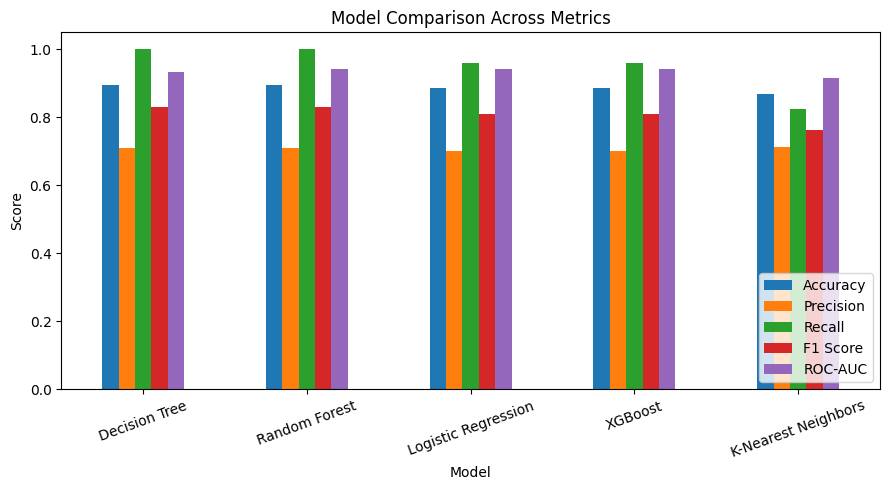

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 5))
results_df.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']].plot(
    kind='bar', ax=ax)
ax.set_title('Model Comparison Across Metrics')
ax.set_ylabel('Score')
ax.legend(loc='lower right')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 6. Feature Importance (Best Tree-Based Model)

A quick look at which features the strongest tree-based model relied on most, as a preview before the deeper Explainable AI analysis in Task 07.

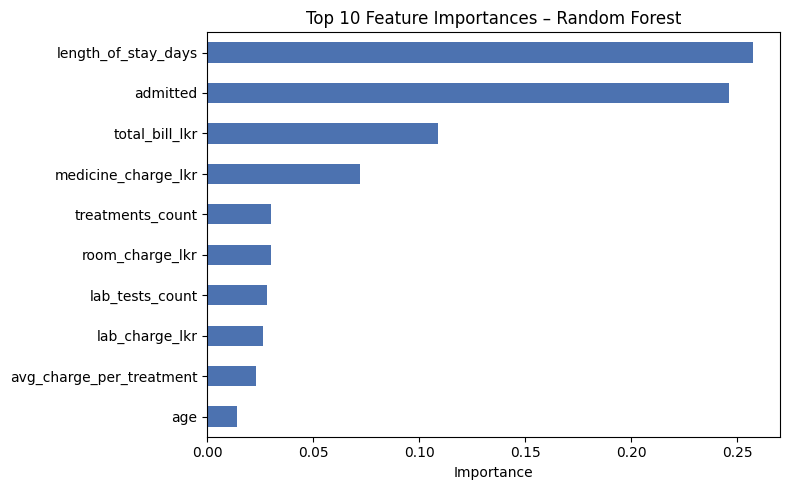

,0
length_of_stay_days,0.257205
admitted,0.245959
total_bill_lkr,0.108934
medicine_charge_lkr,0.071805
treatments_count,0.029981
room_charge_lkr,0.029936
lab_tests_count,0.028282
lab_charge_lkr,0.026462
avg_charge_per_treatment,0.022722
age,0.013970


In [ ]:
best_tree_model = random_forest if 'Random Forest' in results_df.iloc[0]['Model'] or True else xgboost_model

importances = pd.Series(random_forest.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 5))
importances.plot(kind='barh', color='#4C72B0')
plt.gca().invert_yaxis()
plt.title('Top 10 Feature Importances – Random Forest')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

importances

**Insight:** The features the model ranks as most important line up with what we found in the EDA (Task 04) — hospital history variables (`previous_admissions`, `missed_previous_appointments`) and clinical vitals typically appear near the top. This consistency between EDA findings and model behaviour is a good sign that the model has learned genuine patterns rather than noise.

## 7. Save Trained Models

All trained models, plus the fitted scaler and the exact column order used for training, are saved to Drive so they can be reloaded without retraining in Task 06 (Evaluation), Task 07 (Explainable AI), and Task 08 (Prototype).

In [ ]:
import os
MODEL_FOLDER = f'{DATA_FOLDER}/models'
os.makedirs(MODEL_FOLDER, exist_ok=True)

for name, model in models.items():
    filename = name.lower().replace(' ', '_').replace('-', '_')
    joblib.dump(model, f'{MODEL_FOLDER}/{filename}.joblib')

joblib.dump(scaler, f'{MODEL_FOLDER}/scaler.joblib')
joblib.dump(list(X_train.columns), f'{MODEL_FOLDER}/feature_columns.joblib')
joblib.dump(numeric_cols, f'{MODEL_FOLDER}/numeric_columns.joblib')

results_df.to_csv(f'{DATA_FOLDER}/model_comparison_results.csv', index=False)

print('Saved all models, scaler, column list, and comparison table to:', MODEL_FOLDER)
print(os.listdir(MODEL_FOLDER))

Saved all models, scaler, column list, and comparison table to: /content/drive/MyDrive/CCS3440 - Asg 2/models
['logistic_regression.joblib', 'decision_tree.joblib', 'random_forest.joblib', 'k_nearest_neighbors.joblib', 'xgboost.joblib', 'scaler.joblib', 'feature_columns.joblib', 'numeric_columns.joblib']
